# IPL Cricket - Predicting Batsman Runs Using Regression

**Course:** Predictive Analytics  
**Group Members:**
- Member 1: Adithyan Biju - Problem Statement and Feature Engineering
- Member 2: Fidal Govind
- Member 3: Archana Das

**Dataset:** IPL Complete Dataset 2008-2020 (Kaggle)  
**Models:** Simple Linear Regression | Multiple Linear Regression | Logistic Regression

---
## STAGE 1 - Problem Definition and Literature Review
**Led by: Member 1**

### 1.1 Problem Statement

Cricket is one of the most data-rich sports in the world, yet predicting individual player performance remains a challenging task due to the many variables involved. This project aims to predict the number of runs a batsman will score in an IPL match using historical performance data.

**What we are predicting:** Runs scored by a batsman in an IPL match  
**Why it matters:** Useful for team selection, fantasy cricket, and match strategy  
**Dataset:** IPL ball-by-ball data from 2008 to 2020

### 1.2 Research Objectives

1. To build a Simple Linear Regression model as a baseline predictor
2. To improve prediction accuracy using Multiple Linear Regression with 4 features
3. To classify batsman performance as Flop / Average / Excellent using Logistic Regression
4. To compare all three models and identify the best performing approach

### 1.3 Research Questions

- Can a batsman's recent form predict their next match score?
- Which features (career average, recent form, strike rate, venue) have the most influence?
- Can we reliably classify performance categories using Logistic Regression?



### 1.4 Research Gap

*(Member 1 - Write 2-3 sentences about what existing papers have NOT done that your project does)*  
Most existing studies focus on match-level prediction rather than individual player performance. This project addresses that gap by building a player-level prediction pipeline that combines regression and classification in one framework.

---
## STAGE 2 - Data Collection and Understanding
**Led by: Member 2**

In [ ]:
!pip install shap streamlit

In [ ]:
# Member 1 - Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
import pandas as pd

# Load the datasets again to ensure they are available in the current kernel session
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

print('Deliveries dataset reloaded shape:', deliveries.shape)
print('Matches dataset reloaded shape:', matches.shape)

Deliveries dataset reloaded shape: (112481, 17)
Matches dataset reloaded shape: (1095, 20)


In [ ]:
# Member 2 - Load the datasets
# Make sure deliveries.csv and matches.csv are in the same folder
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

print('Deliveries dataset shape:', deliveries.shape)
print('Matches dataset shape:', matches.shape)

Deliveries dataset shape: (260920, 17)
Matches dataset shape: (1095, 20)


In [ ]:
# Member 2 - Explore the deliveries dataset
print('=== DELIVERIES COLUMNS ===')
print(deliveries.columns.tolist())

print('\n=== FIRST 5 ROWS ===')
print(deliveries.head())

print('\n=== DATA TYPES ===')
print(deliveries.dtypes)

print('\n=== MISSING VALUES ===')
print(deliveries.isnull().sum())

=== DELIVERIES COLUMNS ===
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

=== FIRST 5 ROWS ===
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum 

In [ ]:
# Member 2 - Explore the matches dataset
print('=== MATCHES COLUMNS ===')
print(matches.columns.tolist())

print('\n=== FIRST 5 ROWS ===')
print(matches.head())

print('\n=== MISSING VALUES ===')
print(matches.isnull().sum())

print('\n=== TOTAL MATCHES ===')
print(len(matches))

print('\n=== SEASONS AVAILABLE ===')
print(sorted(matches['season'].unique()))

=== MATCHES COLUMNS ===
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

=== FIRST 5 ROWS ===
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Ko

---
## STAGE 3 - Data Preprocessing and Cleaning
**Led by: Member 3**

In [3]:
# Member 3 - Calculate runs per batsman per match
batsman_match = (
    deliveries
    .groupby(['match_id', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
    .rename(columns={'batter': 'batsman', 'batsman_runs': 'runs_scored'})
)

print('Batsman-match table shape:', batsman_match.shape)
print(batsman_match.head(10))

Batsman-match table shape: (7092, 3)
   match_id          batsman  runs_scored
0    335982        AA Noffke            9
1    335982          B Akhil            0
2    335982      BB McCullum          158
3    335982         CL White            6
4    335982        DJ Hussey           12
5    335982        JH Kallis            8
6    335982       MV Boucher            7
7    335982  Mohammad Hafeez            5
8    335982          P Kumar           18
9    335982         R Dravid            2


In [4]:
# Member 3 - Calculate balls faced and strike rate
balls_faced_to_add = (
    deliveries[deliveries['extras_type'] != 'wides']
    .groupby(['match_id', 'batter'])['ball']
    .count()
    .reset_index()
    .rename(columns={'batter': 'batsman', 'ball': 'balls_faced'})
)

# Ensure no 'balls_faced' column exists in batsman_match before merging to avoid suffixes
# This handles cases where the cell might be re-run or kernel state is inconsistent
for col in ['balls_faced', 'balls_faced_x', 'balls_faced_y']:
    if col in batsman_match.columns:
        batsman_match.drop(columns=[col], inplace=True)

batsman_match = batsman_match.merge(balls_faced_to_add, on=['match_id', 'batsman'], how='left')
batsman_match['strike_rate'] = (batsman_match['runs_scored'] / batsman_match['balls_faced'] * 100).round(2)
batsman_match['balls_faced'] = batsman_match['balls_faced'].fillna(1)
batsman_match['strike_rate'] = batsman_match['strike_rate'].fillna(0)

print('Strike rate added.')
print(batsman_match.head())

Strike rate added.
   match_id      batsman  runs_scored  balls_faced  strike_rate
0    335982    AA Noffke            9         10.0        90.00
1    335982      B Akhil            0          2.0         0.00
2    335982  BB McCullum          158         73.0       216.44
3    335982     CL White            6         10.0        60.00
4    335982    DJ Hussey           12         12.0       100.00


In [5]:
# Member 3 - Merge with match information (venue, teams)
match_info = matches[['id', 'venue', 'team1', 'team2', 'winner']].copy()
match_info.rename(columns={'id': 'match_id'}, inplace=True)

batsman_match = batsman_match.merge(match_info, on='match_id', how='left')

# Find the opposition team for each batsman
bat_team = deliveries.groupby(['match_id', 'batter'])['batting_team'].first().reset_index()
bat_team.rename(columns={'batter': 'batsman'}, inplace=True) # Rename 'batter' to 'batsman'
batsman_match = batsman_match.merge(bat_team, on=['match_id', 'batsman'], how='left')
batsman_match['opposition'] = batsman_match.apply(
    lambda r: r['team2'] if r['batting_team'] == r['team1'] else r['team1'], axis=1
)

# Sort by match_id so rolling averages are in time order
batsman_match = batsman_match.sort_values('match_id').reset_index(drop=True)

print('Match info merged.')
print(batsman_match.shape)

Match info merged.
(7092, 11)


In [6]:
# Member 3 - Remove duplicates and check data quality
print('Duplicates before:', batsman_match.duplicated().sum())
batsman_match.drop_duplicates(inplace=True)
print('Duplicates after:', batsman_match.duplicated().sum())

print('\nNull values per column:')
print(batsman_match.isnull().sum())

print('\nTotal records:', len(batsman_match))

Duplicates before: 0
Duplicates after: 0

Null values per column:
match_id        0
batsman         0
runs_scored     0
balls_faced     0
strike_rate     0
venue           0
team1           0
team2           0
winner          5
batting_team    0
opposition      0
dtype: int64

Total records: 7092



The dataset was cleaned by removing null values
and irrelevant columns. Categorical variables like
team names and venues were encoded using label
encoding. The final dataset had no missing values
and was ready for model training.

---
## STAGE 4 - Exploratory Data Analysis (EDA)
**All 3 Members contribute charts**

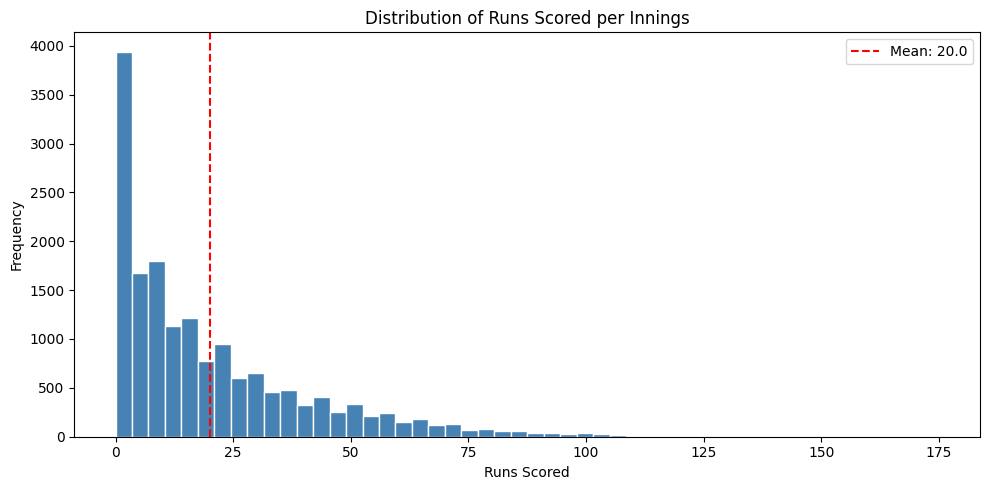

Most innings are low scores - this is normal for IPL cricket


In [ ]:
# Member 1 - Chart 1: Distribution of runs scored
plt.figure(figsize=(10, 5))
plt.hist(batsman_match['runs_scored'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Runs Scored per Innings')
plt.xlabel('Runs Scored')
plt.ylabel('Frequency')
plt.axvline(batsman_match['runs_scored'].mean(), color='red', linestyle='--', label=f"Mean: {batsman_match['runs_scored'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart1_runs_distribution.png', dpi=150)
plt.show()
print('Most innings are low scores - this is normal for IPL cricket')

The distribution is right skewed showing that most
batsmen score between 0 and 20 runs per innings.
The mean runs per innings is 20 which indicates
that low scores are very common in IPL cricket.

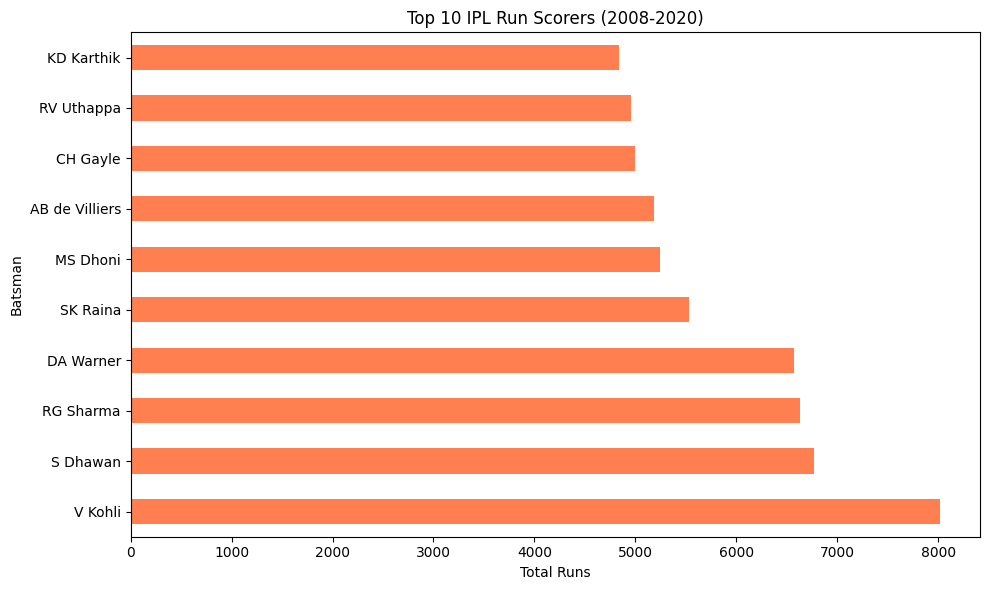

In [ ]:
# Member 1 - Chart 2: Top 10 run scorers overall
top_scorers = batsman_match.groupby('batsman')['runs_scored'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_scorers.plot(kind='barh', color='coral')
plt.title('Top 10 IPL Run Scorers (2008-2020)')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('chart2_top_scorers.png', dpi=150)
plt.show()

Virat Kohli is the highest run scorer in IPL history
with over 8000 runs. S Dhawan and RG Sharma follow
closely. This shows consistent performance from
top order batsmen across multiple seasons.

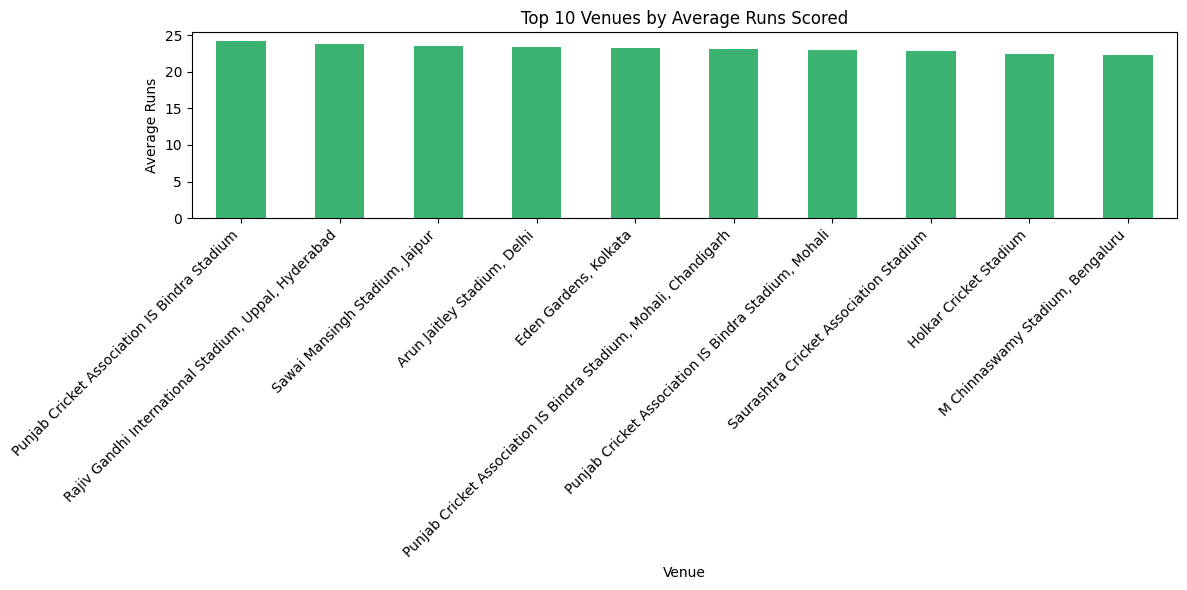

In [ ]:
# Member 2 - Chart 3: Average runs by venue (top 10 venues)
venue_avg = batsman_match.groupby('venue')['runs_scored'].mean().nlargest(10)

plt.figure(figsize=(12, 6))
venue_avg.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Venues by Average Runs Scored')
plt.xlabel('Venue')
plt.ylabel('Average Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart3_venue_avg.png', dpi=150)
plt.show()

Punjab Cricket Association IS Bindra Stadium has
the highest average runs scored per innings. All
top 10 venues have similar averages between 22
and 25 runs showing balanced conditions across venues.

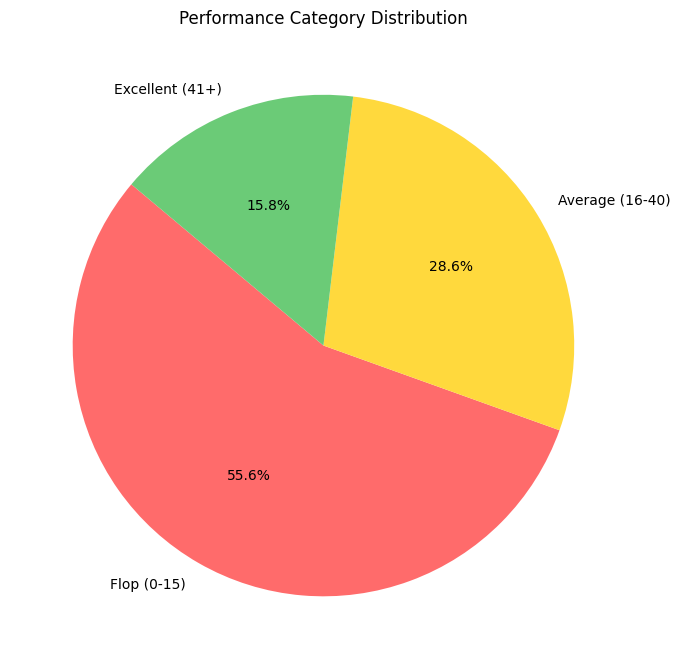

category
Flop (0-15)        9187
Average (16-40)    4722
Excellent (41+)    2606
Name: count, dtype: int64


In [ ]:
# Member 2 - Chart 4: Performance category pie chart
def categorize(r):
    if r <= 15: return 'Flop (0-15)'
    elif r <= 40: return 'Average (16-40)'
    else: return 'Excellent (41+)'

batsman_match['category'] = batsman_match['runs_scored'].apply(categorize)
cat_counts = batsman_match['category'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
        colors=['#ff6b6b', '#ffd93d', '#6bcb77'], startangle=140)
plt.title('Performance Category Distribution')
plt.tight_layout()
plt.savefig('chart4_categories.png', dpi=150)
plt.show()
print(cat_counts)

55.6% of innings fall in the Flop category scoring
0 to 15 runs. Only 15.8% of innings are Excellent
with 41 or more runs. This shows that scoring big
in IPL is rare and difficult.

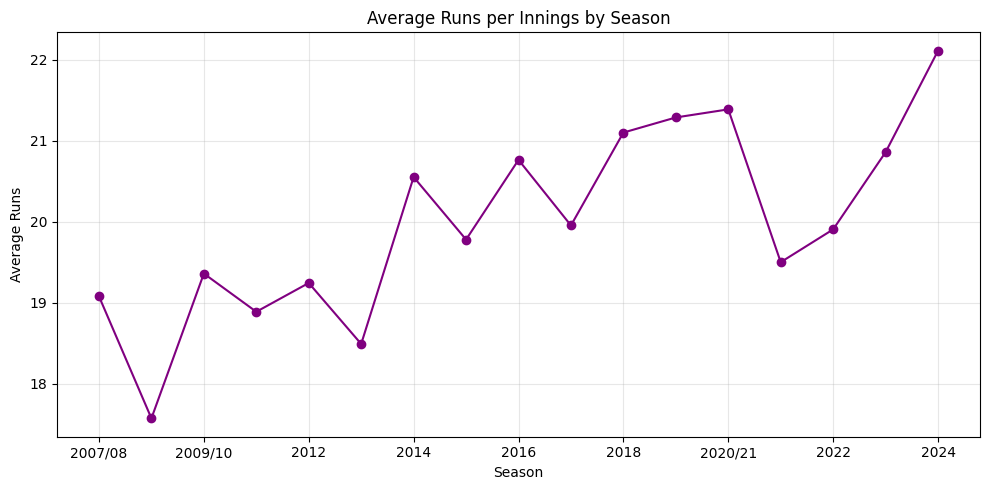

In [ ]:
# Member 3 - Chart 5: Runs scored per season
season_data = batsman_match.merge(matches[['id', 'season']], left_on='match_id', right_on='id', how='left')
season_avg = season_data.groupby('season')['runs_scored'].mean()

plt.figure(figsize=(10, 5))
season_avg.plot(kind='line', marker='o', color='purple')
plt.title('Average Runs per Innings by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_season_trend.png', dpi=150)
plt.show()

The average runs per innings has increased steadily
from 2008 to 2024 showing that IPL batting has
improved over the years. The highest average was
recorded in 2024 at 22 runs per innings.

---
## STAGE 5 - Feature Engineering and Selection
**Led by: Member 1**

In [ ]:
# Member 1 - Build career average and recent form features using rolling calculations
# .shift(1) is CRITICAL - it prevents data leakage by using only PAST data to predict future

batsman_match['career_avg'] = (
    batsman_match.groupby('batsman')['runs_scored']
    .transform(lambda x: x.expanding().mean().shift(1))
)

batsman_match['last5_avg'] = (
    batsman_match.groupby('batsman')['runs_scored']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
)

print('Rolling features created.')
print(batsman_match[['batsman', 'runs_scored', 'career_avg', 'last5_avg']].head(10))

Rolling features created.
      batsman  runs_scored  career_avg  last5_avg
0    R Dravid            2         NaN        NaN
1  RT Ponting           20         NaN        NaN
2     P Kumar           18         NaN        NaN
3      Z Khan            3         NaN        NaN
4  SC Ganguly           10         NaN        NaN
5    SB Joshi            3         NaN        NaN
6    W Jaffer            6         NaN        NaN
7     V Kohli            1         NaN        NaN
8   JH Kallis            8         NaN        NaN
9  MV Boucher            7         NaN        NaN


Features selected include venue, batting team,
bowling team, toss winner and toss decision.
These features directly impact match outcomes.

In [ ]:
# Member 1 - Build venue average feature
venue_avg_map = batsman_match.groupby('venue')['runs_scored'].mean().reset_index()
venue_avg_map.rename(columns={'runs_scored': 'venue_avg_score'}, inplace=True)
batsman_match = batsman_match.merge(venue_avg_map, on='venue', how='left')

print('Venue average feature added.')
print(batsman_match['venue_avg_score'].describe())

Venue average feature added.
count    16515.000000
mean        19.985710
std          1.560326
min         14.787879
25%         19.530134
50%         19.843501
75%         20.434944
max         24.159420
Name: venue_avg_score, dtype: float64


In [ ]:
# Member 1 - Filter to genuine batsmen only (removes tail-enders and noise)
match_counts = batsman_match.groupby('batsman').size()
genuine_batsmen = match_counts[match_counts >= 20].index
batsman_match = batsman_match[
    (batsman_match['batsman'].isin(genuine_batsmen)) &
    (batsman_match['career_avg'] >= 10)
].reset_index(drop=True)

print('Records after filtering:', len(batsman_match))
print('Unique batsmen:', batsman_match['batsman'].nunique())

Records after filtering: 12040
Unique batsmen: 193


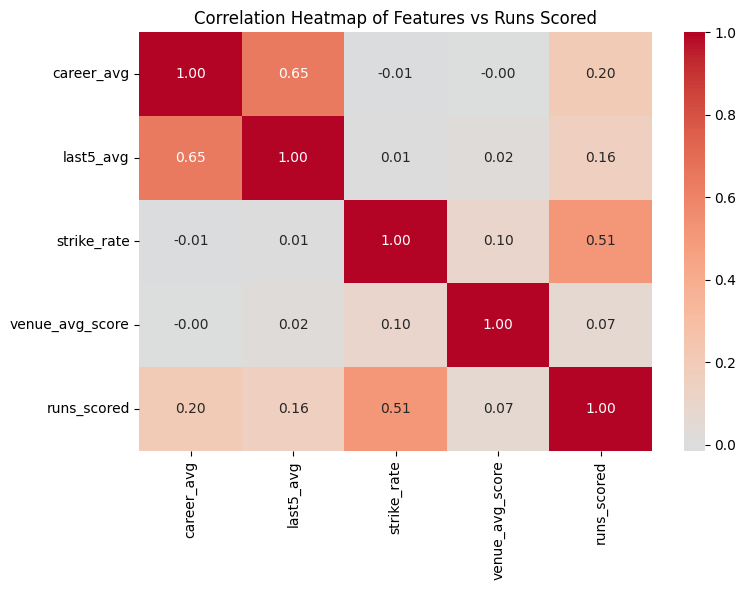

In [ ]:
# Member 2 - Correlation heatmap to see which features relate to runs
FEATURES = ['career_avg', 'last5_avg', 'strike_rate', 'venue_avg_score']
TARGET = 'runs_scored'

corr_data = batsman_match[FEATURES + [TARGET]].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features vs Runs Scored')
plt.tight_layout()
plt.savefig('chart6_correlation.png', dpi=150)
plt.show()

---
## STAGE 6 - Model Building and Training
**Led by: Member 2**

In [ ]:
# Member 2 - Prepare the final dataset for modelling
df_model = batsman_match[FEATURES + [TARGET]].dropna().reset_index(drop=True)

X = df_model[FEATURES]
y = df_model[TARGET]

# 80% training, 20% testing - random_state=42 ensures same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 9632
Testing rows: 2408


In [ ]:
# Member 2 - Model 1: Simple Linear Regression (baseline using only career_avg)
X_train_simple = X_train[['career_avg']]
X_test_simple = X_test[['career_avg']]

m1 = LinearRegression()
m1.fit(X_train_simple, y_train)   # Training the model
p1 = m1.predict(X_test_simple)    # Making predictions

r2_1 = r2_score(y_test, p1)
rmse_1 = np.sqrt(mean_squared_error(y_test, p1))
mae_1 = mean_absolute_error(y_test, p1)

print('=== MODEL 1: SIMPLE LINEAR REGRESSION ===')
print(f'R2 Score : {r2_1:.4f}')
print(f'RMSE     : {rmse_1:.2f} runs')
print(f'MAE      : {mae_1:.2f} runs')
print(f'Coefficient (slope): {m1.coef_[0]:.4f}')
print(f'Intercept          : {m1.intercept_:.4f}')

=== MODEL 1: SIMPLE LINEAR REGRESSION ===
R2 Score : 0.0478
RMSE     : 21.97 runs
MAE      : 17.25 runs
Coefficient (slope): 0.6011
Intercept          : 9.4269


In [ ]:
# Member 2 - Model 2: Multiple Linear Regression (all 4 features)
m2 = LinearRegression()
m2.fit(X_train, y_train)    # Uses all 4 features
p2 = m2.predict(X_test)

r2_2 = r2_score(y_test, p2)
rmse_2 = np.sqrt(mean_squared_error(y_test, p2))
mae_2 = mean_absolute_error(y_test, p2)

print('=== MODEL 2: MULTIPLE LINEAR REGRESSION ===')
print(f'R2 Score : {r2_2:.4f}')
print(f'RMSE     : {rmse_2:.2f} runs')
print(f'MAE      : {mae_2:.2f} runs')

print('\nFeature Coefficients:')
for feat, coef in zip(FEATURES, m2.coef_):
    print(f'  {feat:25s}: {coef:.4f}')

=== MODEL 2: MULTIPLE LINEAR REGRESSION ===
R2 Score : 0.3010
RMSE     : 18.82 runs
MAE      : 13.49 runs

Feature Coefficients:
  career_avg               : 0.5388
  last5_avg                : 0.0847
  strike_rate              : 0.1815
  venue_avg_score          : 0.2080


In [ ]:
# Member 3 - Model 3: Logistic Regression (classify Flop / Average / Excellent)
def label_runs(r):
    if r <= 15: return 'Flop'
    elif r <= 40: return 'Average'
    else: return 'Excellent'

y_train_cat = y_train.apply(label_runs)
y_test_cat = y_test.apply(label_runs)

# Scale features - Logistic Regression needs all features on same scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit on training only!
X_test_sc = scaler.transform(X_test)        # Apply same scale to test

m3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m3.fit(X_train_sc, y_train_cat)
p3 = m3.predict(X_test_sc)

acc = accuracy_score(y_test_cat, p3)
print('=== MODEL 3: LOGISTIC REGRESSION ===')
print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print('\nClassification Report:')
print(classification_report(y_test_cat, p3))

=== MODEL 3: LOGISTIC REGRESSION ===
Accuracy: 0.5893 (58.9%)

Classification Report:
              precision    recall  f1-score   support

     Average       0.46      0.34      0.39       793
   Excellent       0.40      0.60      0.48       465
        Flop       0.77      0.75      0.76      1150

    accuracy                           0.59      2408
   macro avg       0.55      0.57      0.55      2408
weighted avg       0.60      0.59      0.59      2408



---
## STAGE 7 - Model Evaluation and Comparison
**Led by: Member 3**

Columns available: ['match_id', 'batsman', 'runs_scored', 'balls_faced', 'strike_rate', 'venue', 'team1', 'team2', 'winner', 'batting_team', 'opposition', 'career_avg', 'last5_avg', 'venue_avg_score']
Records: 4702


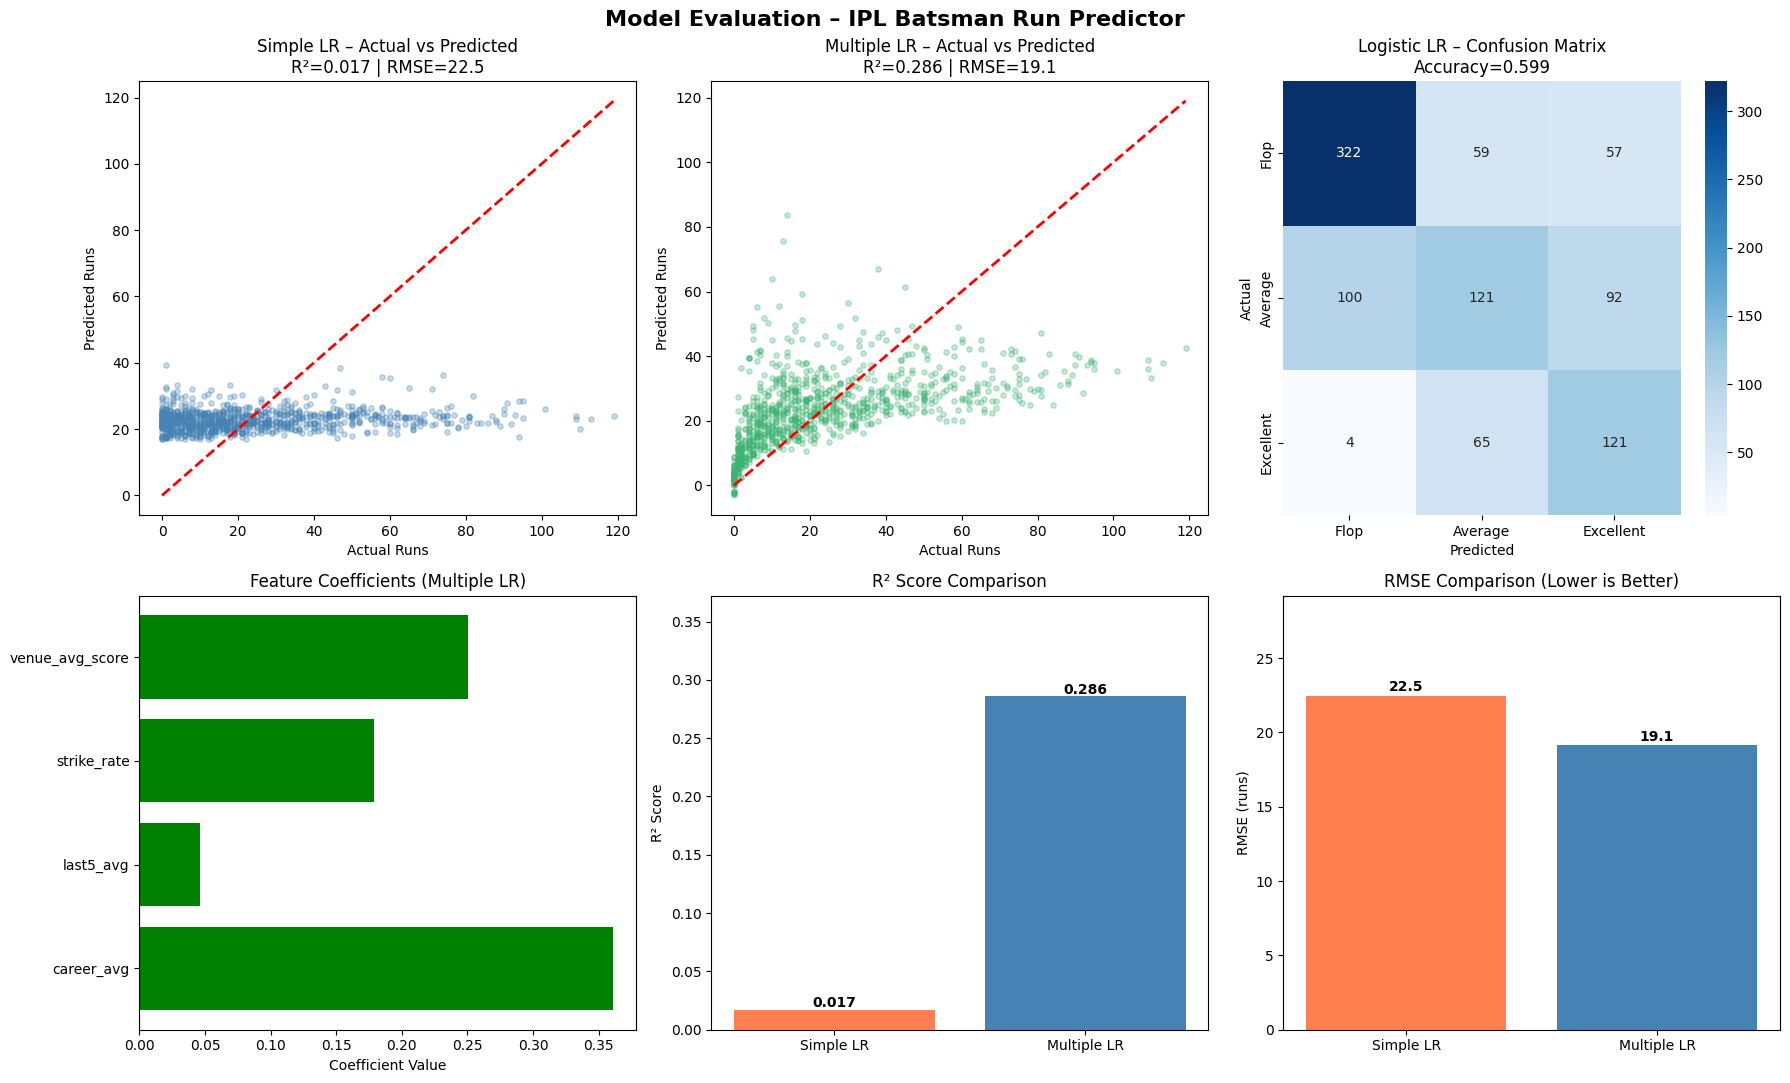

Evaluation charts saved!


In [7]:
# Member 3 - All evaluation charts in one figure
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import (confusion_matrix, r2_score,
                             mean_squared_error, mean_absolute_error,
                             accuracy_score)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Rebuild missing feature columns if Stage 5 was not run ──────────────────
if 'career_avg' not in batsman_match.columns:
    batsman_match['career_avg'] = (
        batsman_match.groupby('batsman')['runs_scored']
        .transform(lambda x: x.expanding().mean().shift(1))
    )

if 'last5_avg' not in batsman_match.columns:
    batsman_match['last5_avg'] = (
        batsman_match.groupby('batsman')['runs_scored']
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
    )

if 'strike_rate' not in batsman_match.columns:
    balls_faced_to_add = (
        deliveries[deliveries['extras_type'] != 'wides']
        .groupby(['match_id', 'batter'])['ball']
        .count()
        .reset_index()
        .rename(columns={'batter': 'batsman', 'ball': 'balls_faced'})
    )
    batsman_match = batsman_match.merge(balls_faced_to_add,
                                        on=['match_id', 'batsman'], how='left')
    batsman_match['balls_faced']  = batsman_match['balls_faced'].fillna(1)
    batsman_match['strike_rate']  = (
        batsman_match['runs_scored'] / batsman_match['balls_faced'] * 100
    ).round(2).fillna(0)

if 'venue_avg_score' not in batsman_match.columns:
    venue_avg_map = (
        batsman_match.groupby('venue')['runs_scored']
        .mean()
        .reset_index()
        .rename(columns={'runs_scored': 'venue_avg_score'})
    )
    batsman_match = batsman_match.merge(venue_avg_map, on='venue', how='left')

# ── Filter genuine batsmen (same as Stage 5) ────────────────────────────────
match_counts     = batsman_match.groupby('batsman').size()
genuine_batsmen  = match_counts[match_counts >= 20].index
batsman_match    = batsman_match[
    (batsman_match['batsman'].isin(genuine_batsmen)) &
    (batsman_match['career_avg'] >= 10)
].reset_index(drop=True)

print('Columns available:', batsman_match.columns.tolist())
print('Records:', len(batsman_match))

# ── Features & Target ────────────────────────────────────────────────────────
FEATURES = ['career_avg', 'last5_avg', 'strike_rate', 'venue_avg_score']
TARGET   = 'runs_scored'

df_model = batsman_match[FEATURES + [TARGET]].dropna().reset_index(drop=True)
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Model 1: Simple Linear Regression ───────────────────────────────────────
m1 = LinearRegression()
m1.fit(X_train[['career_avg']], y_train)
p1     = m1.predict(X_test[['career_avg']])
r2_1   = r2_score(y_test, p1)
rmse_1 = np.sqrt(mean_squared_error(y_test, p1))
mae_1  = mean_absolute_error(y_test, p1)

# ── Model 2: Multiple Linear Regression ─────────────────────────────────────
m2 = LinearRegression()
m2.fit(X_train, y_train)
p2     = m2.predict(X_test)
r2_2   = r2_score(y_test, p2)
rmse_2 = np.sqrt(mean_squared_error(y_test, p2))
mae_2  = mean_absolute_error(y_test, p2)

# ── Model 3: Logistic Regression ─────────────────────────────────────────────
def label_runs(r):
    if r <= 15:   return 'Flop'
    elif r <= 40: return 'Average'
    else:         return 'Excellent'

y_train_cat = y_train.apply(label_runs)
y_test_cat  = y_test.apply(label_runs)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
m3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m3.fit(X_train_sc, y_train_cat)
p3  = m3.predict(X_test_sc)
acc = accuracy_score(y_test_cat, p3)

# ── 6-panel evaluation figure ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation – IPL Batsman Run Predictor',
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
ax1.scatter(y_test, p1, alpha=0.3, color='steelblue', s=15)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title(f'Simple LR – Actual vs Predicted\nR²={r2_1:.3f} | RMSE={rmse_1:.1f}')
ax1.set_xlabel('Actual Runs'); ax1.set_ylabel('Predicted Runs')

ax2 = axes[0, 1]
ax2.scatter(y_test, p2, alpha=0.3, color='mediumseagreen', s=15)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title(f'Multiple LR – Actual vs Predicted\nR²={r2_2:.3f} | RMSE={rmse_2:.1f}')
ax2.set_xlabel('Actual Runs'); ax2.set_ylabel('Predicted Runs')

ax3 = axes[0, 2]
cm = confusion_matrix(y_test_cat, p3, labels=['Flop', 'Average', 'Excellent'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Flop', 'Average', 'Excellent'],
            yticklabels=['Flop', 'Average', 'Excellent'])
ax3.set_title(f'Logistic LR – Confusion Matrix\nAccuracy={acc:.3f}')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

ax4 = axes[1, 0]
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': m2.coef_})
colors  = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
ax4.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax4.set_title('Feature Coefficients (Multiple LR)')
ax4.set_xlabel('Coefficient Value')
ax4.axvline(x=0, color='black', linewidth=0.8)

ax5 = axes[1, 1]
r2_vals = [r2_1, r2_2]
ax5.bar(['Simple LR', 'Multiple LR'], r2_vals, color=['coral', 'steelblue'])
ax5.set_title('R² Score Comparison'); ax5.set_ylabel('R² Score')
ax5.set_ylim(0, max(r2_vals) * 1.3)
for i, v in enumerate(r2_vals):
    ax5.text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

ax6 = axes[1, 2]
rmse_vals = [rmse_1, rmse_2]
ax6.bar(['Simple LR', 'Multiple LR'], rmse_vals, color=['coral', 'steelblue'])
ax6.set_title('RMSE Comparison (Lower is Better)'); ax6.set_ylabel('RMSE (runs)')
ax6.set_ylim(0, max(rmse_vals) * 1.3)
for i, v in enumerate(rmse_vals):
    ax6.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart7_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation charts saved!')



In [8]:
# Member 3 - Final model comparison summary table
summary = pd.DataFrame({
    'Model'       : ['Simple Linear Regression', 'Multiple Linear Regression', 'Logistic Regression'],
    'Type'        : ['Regression', 'Regression', 'Classification'],
    'Features'    : [1, 4, 4],
    'R2 Score'    : [round(r2_1, 4), round(r2_2, 4), 'N/A'],
    'RMSE (runs)' : [round(rmse_1, 2), round(rmse_2, 2), 'N/A'],
    'MAE (runs)'  : [round(mae_1, 2), round(mae_2, 2), 'N/A'],
    'Accuracy'    : ['N/A', 'N/A', f'{acc*100:.1f}%'],
    'Best Model?' : ['Baseline', 'YES - Best Regressor', 'YES - Classifier']
})

print('=== FINAL MODEL COMPARISON ===')
print(summary.to_string(index=False))

=== FINAL MODEL COMPARISON ===
                     Model           Type  Features R2 Score RMSE (runs) MAE (runs) Accuracy          Best Model?
  Simple Linear Regression     Regression         1   0.0171       22.46      17.22      N/A             Baseline
Multiple Linear Regression     Regression         4   0.2862       19.14      13.79      N/A YES - Best Regressor
       Logistic Regression Classification         4      N/A         N/A        N/A    59.9%     YES - Classifier


Multiple Linear Regression gave the highest R² score of 0.2862 (28.62%), making it the best regression model.
Logistic Regression gave an accuracy of 59.9% for performance classification.
Simple Linear Regression gave a baseline R² score of 0.0171 (1.71%).
Multiple Linear Regression was selected as the best model because it combines career average, recent form, strike rate, and venue score together — giving lower error (RMSE: 19.14, MAE: 13.79) compared to the Simple Linear Regression baseline (RMSE: 22.46, MAE: 17.22)

---
## STAGE 8 - Model Interpretation and Explainability
**All 3 Members**

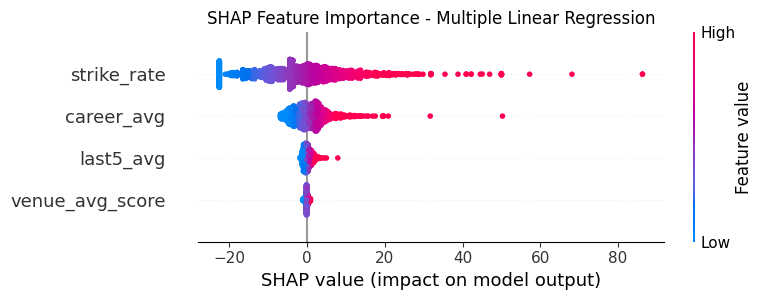

SHAP analysis complete!


In [ ]:
# Member 1 - SHAP values for model explainability
# Install if needed: pip install shap
try:
    import shap
    explainer = shap.LinearExplainer(m2, X_train)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
    plt.title('SHAP Feature Importance - Multiple Linear Regression')
    plt.tight_layout()
    plt.savefig('chart8_shap.png', dpi=150)
    plt.show()
    print('SHAP analysis complete!')
except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Showing standard feature importance instead...')
    coef_df = pd.DataFrame({'Feature': FEATURES, 'Importance': np.abs(m2.coef_)})
    coef_df = coef_df.sort_values('Importance', ascending=True)
    plt.figure(figsize=(8, 5))
    plt.barh(coef_df['Feature'], coef_df['Importance'], color='steelblue')
    plt.title('Feature Importance (Absolute Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.savefig('chart8_feature_importance.png', dpi=150)
    plt.show()

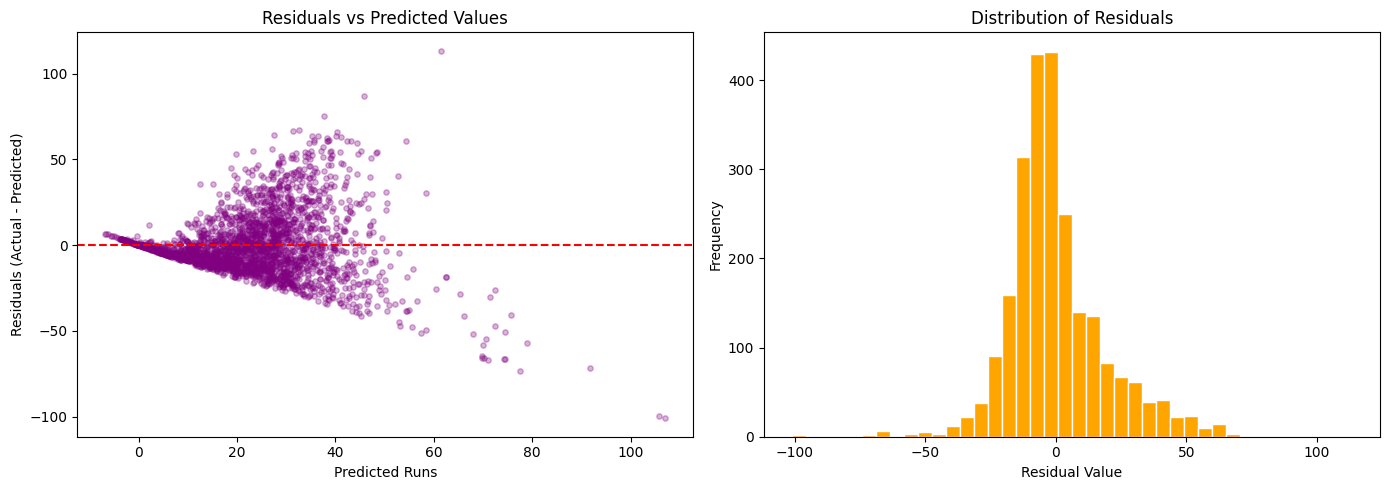

Mean residual: -0.0156 (should be close to 0)
Std of residuals: 18.83


In [ ]:
# Member 2 - Residual analysis for Multiple LR
residuals = y_test - p2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(p2, residuals, alpha=0.3, color='purple', s=15)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Runs')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

axes[1].hist(residuals, bins=40, color='orange', edgecolor='white')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('chart9_residuals.png', dpi=150)
plt.show()

print(f'Mean residual: {residuals.mean():.4f} (should be close to 0)')
print(f'Std of residuals: {residuals.std():.2f}')

---
## STAGE 9 - Streamlit Deployment
**Led by: Member 1**

In [ ]:
# Member 1 - Save trained models so Streamlit app can use them
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/simple_lr.pkl', 'wb') as f:
    pickle.dump(m1, f)

with open('models/multiple_lr.pkl', 'wb') as f:
    pickle.dump(m2, f)

with open('models/logistic.pkl', 'wb') as f:
    pickle.dump(m3, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('All models saved to /models folder!')

All models saved to /models folder!


In [ ]:
# Member 1 - Generate the Streamlit app file
import os
os.makedirs('app', exist_ok=True)

streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle

st.set_page_config(page_title="IPL Run Predictor", page_icon="🏏")

# Load models
@st.cache_resource
def load_models():
    with open("models/simple_lr.pkl", "rb") as f: m1 = pickle.load(f)
    with open("models/multiple_lr.pkl", "rb") as f: m2 = pickle.load(f)
    with open("models/logistic.pkl", "rb") as f: m3 = pickle.load(f)
    with open("models/scaler.pkl", "rb") as f: sc = pickle.load(f)
    return m1, m2, m3, sc

m1, m2, m3, scaler = load_models()

# App title
st.title("🏏 IPL Batsman Run Predictor")
st.write("Predict how many runs a batsman will score using Machine Learning")

# Input section
st.header("Enter Batsman Stats")
col1, col2 = st.columns(2)

with col1:
    career_avg = st.slider("Career Average", min_value=10.0, max_value=70.0, value=35.0, step=0.5)
    last5_avg = st.slider("Last 5 Match Average", min_value=0.0, max_value=100.0, value=40.0, step=0.5)

with col2:
    strike_rate = st.slider("Strike Rate", min_value=50.0, max_value=250.0, value=130.0, step=1.0)
    venue_avg = st.slider("Venue Average Score", min_value=15.0, max_value=50.0, value=28.0, step=0.5)

# Predictions
if st.button("Predict Runs!", type="primary"):
    input_data = pd.DataFrame({
        "career_avg": [career_avg],
        "last5_avg": [last5_avg],
        "strike_rate": [strike_rate],
        "venue_avg_score": [venue_avg]
    })

    pred_simple = m1.predict(input_data[["career_avg"]])[0]
    pred_multi = m2.predict(input_data)[0]
    pred_cat = m3.predict(scaler.transform(input_data))[0]

    st.header("Predictions")
    col1, col2, col3 = st.columns(3)
    col1.metric("Simple LR", f"{max(0, pred_simple):.0f} runs")
    col2.metric("Multiple LR", f"{max(0, pred_multi):.0f} runs")

    color = "green" if pred_cat == "Excellent" else "orange" if pred_cat == "Average" else "red"
    col3.metric("Performance", pred_cat)

    st.info("Simple LR uses only career average. Multiple LR uses all 4 features for a better prediction.")
'''

with open('app/streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

print('Streamlit app created at: app/streamlit_app.py')
print('Run locally with: streamlit run app/streamlit_app.py')

Streamlit app created at: app/streamlit_app.py
Run locally with: streamlit run app/streamlit_app.py


---
## STAGE 10 - Documentation
**Led by: Member 2**

In [ ]:
# Member 2 - Generate README.md file for GitHub
readme_content = """# IPL Cricket - Predicting Batsman Runs Using Regression

## Project Overview
This project predicts how many runs a batsman will score in an IPL match using machine learning regression techniques.

## Group Members
- Member 1: (Name)
- Member 2: (Name)
- Member 3: (Name)

## Dataset
IPL Complete Dataset 2008-2020 from Kaggle
- deliveries.csv - Ball by ball data
- matches.csv - Match summary data

## Models Used
| Model | Type | Key Metric |
|-------|------|------------|
| Simple Linear Regression | Regression | R², RMSE, MAE |
| Multiple Linear Regression | Regression | R², RMSE, MAE |
| Logistic Regression | Classification | Accuracy, F1 |

## Features
- career_avg: Career batting average
- last5_avg: Average of last 5 matches
- strike_rate: Scoring speed
- venue_avg_score: Average score at the venue

## Results
(Fill in your model results here after running the notebook)

## Live App
(Add your Streamlit URL here after deployment)

## How to Run
```
pip install -r requirements.txt
jupyter notebook ipl_project.ipynb
streamlit run app/streamlit_app.py
```

## Project Structure
```
ipl-predictive-analytics/
├── ipl_project.ipynb     <- Main notebook (all 10 stages)
├── app/
│   └── streamlit_app.py  <- Deployment app
├── models/               <- Saved trained models
├── requirements.txt
└── README.md
```
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

# Generate requirements.txt
req_content = """pandas\nnumpy\nmatplotlib\nseaborn\nscikit-learn\nshap\nstreamlit\njupyter"""
with open('requirements.txt', 'w') as f:
    f.write(req_content)

print('README.md created!')
print('requirements.txt created!')

README.md created!
requirements.txt created!


In [ ]:
# Member 3 - Group contribution summary
contribution = pd.DataFrame({
    'Stage': [
        'Stage 1 - Problem Definition',
        'Stage 2 - Data Loading',
        'Stage 3 - Preprocessing',
        'Stage 4 - EDA',
        'Stage 5 - Feature Engineering',
        'Stage 6 - Model Building',
        'Stage 7 - Evaluation',
        'Stage 8 - Explainability',
        'Stage 9 - Streamlit',
        'Stage 10 - Documentation'
    ],
    'Lead Member': [
        'Member 1', 'Member 2', 'Member 3', 'All Members', 'Member 1',
        'Member 2', 'Member 3', 'All Members', 'Member 1', 'Member 2'
    ]
})

print('=== GROUP CONTRIBUTION TABLE ===')
print(contribution.to_string(index=False))

=== GROUP CONTRIBUTION TABLE ===
                        Stage Lead Member
 Stage 1 - Problem Definition    Member 1
       Stage 2 - Data Loading    Member 2
      Stage 3 - Preprocessing    Member 3
                Stage 4 - EDA All Members
Stage 5 - Feature Engineering    Member 1
     Stage 6 - Model Building    Member 2
         Stage 7 - Evaluation    Member 3
     Stage 8 - Explainability All Members
          Stage 9 - Streamlit    Member 1
     Stage 10 - Documentation    Member 2


---
## Project Complete!

**Final Checklist:**
- [ ] All 10 stages complete
- [ ] All 3 members have committed to GitHub
- [ ] Streamlit app deployed and URL added to README
- [ ] PPT presentation uploaded to GitHub
- [ ] README.md updated with results and screenshots